# **FineTuneWavLMV2_Optuna_Final.ipynb**

## **WavLM + LoRA + Optuna + Final 10 Runs (Strict Split)**

### **Tujuan:**
1. *Hyperparameter tuning dengan Optuna*
2. *Pilih config terbaik berdasarkan val S = 1 - MAE_mean*
3. *Final evaluation 10 run dengan fixed distinct seeds*
4. *Save semua artifact: grafik, CSV, checkpoint, logs*
5. *Ekspor best-val / median / ensemble CSV untuk kebutuhan analisis & lampiran*


In [1]:
import sys
print(sys.executable)

/venv/main/bin/python


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

Cell 2 — Install library

In [3]:
import os
import gc
import io
import json
import math
import time
import random
import shutil
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import soundfile as sf
import librosa

from sklearn.metrics import r2_score

import optuna
from optuna.trial import TrialState

from transformers import AutoFeatureExtractor, WavLMModel, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model

warnings.filterwarnings("ignore")

Cell 4 — Root, folder architecture, tree summary

In [4]:
# =========================
# ROOT & folder architecture
# =========================
ROOT = Path("/workspace/finetunev2")
NOTEBOOKS = ROOT / "notebooks"
DATA = ROOT / "data"

OUTPUTS = ROOT / "outputs"
CHECKPOINTS = ROOT / "checkpoints"
LOGS = ROOT / "logs"
CACHE = ROOT / "cache"

OUT_OPTUNA_STUDY = OUTPUTS / "optuna_study"
OUT_OPTUNA_TRIALS = OUTPUTS / "optuna_trials"
OUT_FINAL_RUNS = OUTPUTS / "final_runs"
OUT_FINAL_AGG = OUTPUTS / "final_aggregate"
OUT_FINAL_SELECTED = OUTPUTS / "final_selected"
OUT_APPENDIX = OUTPUTS / "appendix_ready"

CKPT_OPTUNA_TRIALS = CHECKPOINTS / "optuna_trials"
CKPT_FINAL_RUNS = CHECKPOINTS / "final_runs"
CKPT_FINAL_SELECTED = CHECKPOINTS / "final_selected"

CKPT_SELECTED_BEST = CKPT_FINAL_SELECTED / "best_val"
CKPT_SELECTED_MEDIAN = CKPT_FINAL_SELECTED / "median"
CKPT_SELECTED_ENSEMBLE = CKPT_FINAL_SELECTED / "ensemble_sources"

HF_CACHE = CACHE / "hf_cache"
TMP_CACHE = CACHE / "tmp"

for p in [
    ROOT, NOTEBOOKS, DATA,
    OUTPUTS, CHECKPOINTS, LOGS, CACHE,
    OUT_OPTUNA_STUDY, OUT_OPTUNA_TRIALS, OUT_FINAL_RUNS, OUT_FINAL_AGG, OUT_FINAL_SELECTED, OUT_APPENDIX,
    CKPT_OPTUNA_TRIALS, CKPT_FINAL_RUNS, CKPT_FINAL_SELECTED,
    CKPT_SELECTED_BEST, CKPT_SELECTED_MEDIAN, CKPT_SELECTED_ENSEMBLE,
    HF_CACHE, TMP_CACHE
]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE)
os.environ["HF_HUB_CACHE"] = str(HF_CACHE)

STUDY_LOG = LOGS / "study_run.log"
TRIAL_FAIL_LOG = LOGS / "trial_failures.log"

def print_tree(root: Path, max_depth: int = 2, indent: str = ""):
    if max_depth < 0 or not root.exists():
        return
    print(f"{indent}{root.name}/")
    if max_depth == 0:
        return
    items = sorted(root.iterdir(), key=lambda x: (x.is_file(), x.name))
    for item in items:
        if item.is_dir():
            print_tree(item, max_depth=max_depth - 1, indent=indent + "  ")
        else:
            print(f"{indent}  {item.name}")

print("ROOT:", ROOT)
print_tree(ROOT, max_depth=2)

ROOT: /workspace/finetunev2
finetunev2/
  .ipynb_checkpoints/
  cache/
    hf_cache/
    tmp/
  checkpoints/
    final_runs/
    final_selected/
    optuna_trials/
  data/
    .ipynb_checkpoints/
    preprocessed_full/
    manifest_strict.csv
    manifest_strict_vast.csv
    preprocessed_full.zip
  logs/
  notebooks/
    .ipynb_checkpoints/
    FineTuneWavLMV2_Optuna.ipynb
  outputs/
    appendix_ready/
    final_aggregate/
    final_runs/
    final_selected/
    optuna_study/
    optuna_trials/


Cell 5 — Global config

In [5]:
# =========================
# Global config
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP_ENABLED = (DEVICE == "cuda")

MODEL_NAME = "microsoft/wavlm-base-plus"
SR_TARGET = 16000
MAX_SEC = 15.0
MAX_LEN = int(SR_TARGET * MAX_SEC)

# Manifest columns
SOURCE_AUDIO_COL = "audio_out"
AUDIO_COL = "audio_path"
CLIP_ID_COL = "clip_id"
GROUP_ID_COL = "group_id"
SPLIT_COL = "split_strict"

TRAIN_SPLIT_VALUE = "train"
VAL_SPLIT_VALUE = "val"
TEST_SPLIT_VALUE = "test"

LABEL_COLS = ["extraversion", "neuroticism", "agreeableness", "conscientiousness", "openness"]

# Fixed training config
BATCH_SIZE = 40
GRAD_ACCUM_STEPS = 1
MAX_EPOCHS = 100
PATIENCE = 5
MIN_DELTA = 0.0
GRAD_CLIP = 1.0
HEAD_DROPOUT = 0.1

NUM_WORKERS = 0
PIN_MEMORY = (DEVICE == "cuda")
PERSISTENT_WORKERS = False

# Optuna
N_TRIALS = 50
OPTUNA_TOPK = 5
OPTUNA_SEED = 42
SELECTION_METRIC = "S"

# Final runs
FINAL_SEEDS = [42, 52, 62, 72, 82, 92, 102, 112, 122, 132]
N_FINAL_RUNS = len(FINAL_SEEDS)

# Display flags:
# False = tetap save ke file, tapi tidak ditampilkan di notebook
# True  = save ke file dan tampil di notebook
DISPLAY_TRIAL_PLOTS = False
DISPLAY_FINAL_RUN_PLOTS = False
DISPLAY_SUMMARY_PLOTS = True

PRUNER = optuna.pruners.MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=8,
    interval_steps=1,
    n_min_trials=5
)

print("DEVICE:", DEVICE)
print("AMP_ENABLED:", AMP_ENABLED)
print("MODEL_NAME:", MODEL_NAME)
print("BATCH_SIZE:", BATCH_SIZE)
print("GRAD_ACCUM_STEPS:", GRAD_ACCUM_STEPS)
print("MAX_EPOCHS:", MAX_EPOCHS)
print("PATIENCE:", PATIENCE)
print("FINAL_SEEDS:", FINAL_SEEDS)
print("PRUNER:", PRUNER)

DEVICE: cuda
AMP_ENABLED: True
MODEL_NAME: microsoft/wavlm-base-plus
BATCH_SIZE: 40
GRAD_ACCUM_STEPS: 1
MAX_EPOCHS: 100
PATIENCE: 5
FINAL_SEEDS: [42, 52, 62, 72, 82, 92, 102, 112, 122, 132]
PRUNER: <optuna.pruners._median.MedianPruner object at 0x76b93b31b020>


Cell 6 — Utilities: logging, seed, save helpers, flush

In [6]:
# =========================
# Utilities
# =========================
def log_line(msg: str, log_path: Optional[Path] = None, also_print: bool = True):
    ts = time.strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {msg}"
    if also_print:
        print(line)
    if log_path is not None:
        with open(log_path, "a", encoding="utf-8") as f:
            f.write(line + "\n")

def save_text(text: str, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        f.write(text)

def append_jsonl(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

def set_seed(seed: int):
    # Seed list memang fixed, tapi fungsi ini tetap perlu
    # untuk benar-benar menerapkan seed ke Python / NumPy / Torch.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def save_csv(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

def copy_if_exists(src: Path, dst: Path):
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(src, dst)

def safe_to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def gpu_flush(reset_peak: bool = True):
    gc.collect()
    plt.close("all")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        if reset_peak:
            try:
                torch.cuda.reset_peak_memory_stats()
            except Exception:
                pass

def del_and_flush(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gpu_flush()

Cell 7 — Prepare manifest_strict_vast.csv

In [7]:
# =========================
# Manifest strict -> manifest strict vast
# =========================
MANIFEST = DATA / "manifest_strict.csv"
AUDIO_DIR = DATA / "preprocessed_full" / "preprocessed_full" 

assert MANIFEST.exists(), f"Manifest not found: {MANIFEST}"
assert AUDIO_DIR.exists(), f"Audio dir not found: {AUDIO_DIR}"

df_manifest = pd.read_csv(MANIFEST)
print("rows:", len(df_manifest))
print("cols:", df_manifest.columns.tolist())

assert SPLIT_COL in df_manifest.columns, f"Kolom split '{SPLIT_COL}' tidak ada. Ada: {df_manifest.columns.tolist()}"
print(df_manifest[SPLIT_COL].value_counts(dropna=False))

missing = [c for c in LABEL_COLS if c not in df_manifest.columns]
print("missing label cols:", missing)
assert not missing, "Label kolom Big Five belum match. Edit LABEL_COLS."

assert SOURCE_AUDIO_COL in df_manifest.columns, f"Kolom audio '{SOURCE_AUDIO_COL}' tidak ada. Edit SOURCE_AUDIO_COL."

print("AUDIO_ROOT used:", AUDIO_DIR)

df_manifest[AUDIO_COL] = df_manifest[SOURCE_AUDIO_COL].apply(lambda s: str(AUDIO_DIR / Path(str(s)).name))

exists = df_manifest[AUDIO_COL].apply(lambda s: Path(s).exists())
print("✅ audio exists:", int(exists.sum()), "/", len(exists))

missing_audio = df_manifest.loc[~exists, [CLIP_ID_COL, SOURCE_AUDIO_COL, AUDIO_COL]].copy()
missing_csv = DATA / "manifest_missing_audio.csv"

if len(missing_audio) > 0:
    save_csv(missing_audio, missing_csv)
    print("⚠️ missing audio count:", len(missing_audio))
    print("Saved missing list to:", missing_csv)
    display(missing_audio.head(10))

assert exists.all(), (
    f"Masih ada audio yang tidak ditemukan: {int((~exists).sum())} file. "
    f"Cek {missing_csv} lalu upload/rename file yang kurang dulu."
)

OUT_MANIFEST = DATA / "manifest_strict_vast.csv"
df_manifest.to_csv(OUT_MANIFEST, index=False)
print("Saved:", OUT_MANIFEST)

rows: 9974
cols: ['clip_id', 'group_id', 'audio_out', 'gender', 'ethnicity', 'age_group', 'avg_trait', 'extraversion', 'neuroticism', 'agreeableness', 'conscientiousness', 'openness', 'split_official', 'split_strict']
split_strict
train    5936
test     2039
val      1999
Name: count, dtype: int64
missing label cols: []
AUDIO_ROOT used: /workspace/finetunev2/data/preprocessed_full/preprocessed_full
✅ audio exists: 9974 / 9974
Saved: /workspace/finetunev2/data/manifest_strict_vast.csv


Cell 8 — Load manifest_strict_vast.csv and split

In [8]:
# =========================
# Load manifest_strict_vast.csv
# =========================
MANIFEST_VAST = DATA / "manifest_strict_vast.csv"
assert MANIFEST_VAST.exists(), f"Missing: {MANIFEST_VAST}"

df = pd.read_csv(MANIFEST_VAST)

required_cols = [CLIP_ID_COL, GROUP_ID_COL, AUDIO_COL, SPLIT_COL] + LABEL_COLS
for c in required_cols:
    assert c in df.columns, f"Missing col: {c}"

df_train = df[df[SPLIT_COL] == TRAIN_SPLIT_VALUE].copy().reset_index(drop=True)
df_val   = df[df[SPLIT_COL] == VAL_SPLIT_VALUE].copy().reset_index(drop=True)
df_test  = df[df[SPLIT_COL] == TEST_SPLIT_VALUE].copy().reset_index(drop=True)

assert len(df_train) > 0, "df_train kosong"
assert len(df_val) > 0, "df_val kosong"
assert len(df_test) > 0, "df_test kosong"

print("train/val/test:", len(df_train), len(df_val), len(df_test))
display(df[[CLIP_ID_COL, GROUP_ID_COL, SPLIT_COL, AUDIO_COL] + LABEL_COLS].head())

train/val/test: 5936 1999 2039


,clip_id,group_id,split_strict,audio_path,extraversion,neuroticism,agreeableness,conscientiousness,openness
0,-10-QQDO_ME.001,-10-QQDO_ME,test,/workspace/finetunev2/data/preprocessed_full/p...,0.532710,0.416667,0.549451,0.563107,0.655556
1,-10-QQDO_ME.002,-10-QQDO_ME,test,/workspace/finetunev2/data/preprocessed_full/p...,0.579439,0.531250,0.670330,0.582524,0.655556
2,-10-QQDO_ME.005,-10-QQDO_ME,test,/workspace/finetunev2/data/preprocessed_full/p...,0.532710,0.552083,0.516484,0.611650,0.633333
3,-IK--4uz5ZY.000,-IK--4uz5ZY,test,/workspace/finetunev2/data/preprocessed_full/p...,0.579439,0.562500,0.604396,0.679612,0.588889
4,-IK--4uz5ZY.002,-IK--4uz5ZY,test,/workspace/finetunev2/data/preprocessed_full/p...,0.542056,0.635417,0.527473,0.660194,0.566667


Cell 9 — Dataset and DataLoader

In [9]:
# =========================
# Dataset & DataLoader
# =========================
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)

def trim_pad_wav(wav: np.ndarray) -> np.ndarray:
    if wav.shape[0] > MAX_LEN:
        return wav[:MAX_LEN]
    if wav.shape[0] < MAX_LEN:
        return np.pad(wav, (0, MAX_LEN - wav.shape[0]), mode="constant")
    return wav

class StrictAudioDataset(Dataset):
    def __init__(self, df_: pd.DataFrame):
        self.df = df_.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        audio_path = Path(row[AUDIO_COL])

        try:
            wav, sr = sf.read(audio_path)
        except Exception as e:
            raise RuntimeError(f"Gagal baca audio: {audio_path} | {repr(e)}")

        if wav.ndim > 1:
            wav = wav.mean(axis=1)

        wav = wav.astype(np.float32)

        if sr != SR_TARGET:
            wav = librosa.resample(wav, orig_sr=sr, target_sr=SR_TARGET)
            wav = wav.astype(np.float32)  # <- hardening penting

        wav = trim_pad_wav(wav)
        wav = wav.astype(np.float32)

        y = np.array([row[c] for c in LABEL_COLS], dtype=np.float32)
        clip_id = str(row[CLIP_ID_COL])

        return wav, y, clip_id

def collate_fn(batch):
    wavs, ys, clip_ids = zip(*batch)
    feats = feature_extractor(
        list(wavs),
        sampling_rate=SR_TARGET,
        return_tensors="pt",
        padding=True
    )
    y = torch.tensor(np.stack(ys), dtype=torch.float32)
    return feats, y, list(clip_ids)

def make_loaders(df_tr: pd.DataFrame, df_va: pd.DataFrame, batch_size: int):
    train_ds = StrictAudioDataset(df_tr)
    val_ds = StrictAudioDataset(df_va)

    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=False,
        collate_fn=collate_fn
    )

    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return train_dl, val_dl

def make_test_loader(df_te: pd.DataFrame, batch_size: int):
    test_ds = StrictAudioDataset(df_te)
    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=False,
        collate_fn=collate_fn
    )
    return test_dl

Cell 10 — Model WavLM + LoRA + head

In [10]:
# =========================
# Model
# =========================
class WavLMWithHead(nn.Module):
    def __init__(
        self,
        backbone_name: str,
        r: int,
        lora_alpha: int = 32,
        lora_dropout: float = 0.05,
        head_dropout: float = 0.1,
    ):
        super().__init__()

        base = WavLMModel.from_pretrained(backbone_name)
        for p in base.parameters():
            p.requires_grad = False

        lora_cfg = LoraConfig(
            r=r,
            lora_alpha=lora_alpha,
            lora_dropout=lora_dropout,
            target_modules=["q_proj", "v_proj"],
            bias="none",
        )
        self.backbone = get_peft_model(base, lora_cfg)

        hidden = base.config.hidden_size
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(head_dropout),
            nn.Linear(256, len(LABEL_COLS)),
            nn.Sigmoid(),
        )

    def mean_pool(self, x, attn_mask=None):
        if attn_mask is None:
            return x.mean(dim=1)
        m = attn_mask.unsqueeze(-1).type_as(x)
        return (x * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)

    def _get_feat_mask_safe(self, hidden_states, attention_mask):
        try:
            base_model = self.backbone.get_base_model() if hasattr(self.backbone, "get_base_model") else self.backbone
            if hasattr(base_model, "_get_feature_vector_attention_mask"):
                return base_model._get_feature_vector_attention_mask(hidden_states.shape[1], attention_mask)
        except Exception:
            pass
        return None

    def forward(self, input_values, attention_mask=None):
        out = self.backbone(input_values=input_values, attention_mask=attention_mask)
        h = out.last_hidden_state

        feat_mask = None
        if attention_mask is not None:
            feat_mask = self._get_feat_mask_safe(h, attention_mask)

        pooled = self.mean_pool(h, feat_mask)
        return self.head(pooled)

def trainable_params(model: nn.Module):
    return [p for p in model.parameters() if p.requires_grad]

def count_params(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

_tmp_model = WavLMWithHead(MODEL_NAME, r=8).to(DEVICE)
_total, _trainable = count_params(_tmp_model)
print(f"Total params: {_total:,}")
print(f"Trainable params: {_trainable:,} ({100*_trainable/_total:.4f}%)")
del_and_flush(_tmp_model)

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

Total params: 94,874,997
Trainable params: 493,061 (0.5197%)


Cell 11 — Metrics

In [11]:
# =========================
# Metrics
# =========================
def compute_metrics_from_arrays(y_true: np.ndarray, y_pred: np.ndarray) -> Dict:
    mae_per = np.mean(np.abs(y_pred - y_true), axis=0)
    mae_mean = float(np.mean(mae_per))

    rmse_per = np.sqrt(np.mean((y_pred - y_true) ** 2, axis=0))
    rmse_mean = float(np.mean(rmse_per))

    r2_per = []
    for j in range(y_true.shape[1]):
        yt = y_true[:, j]
        yp = y_pred[:, j]
        sst = float(np.sum((yt - np.mean(yt)) ** 2))
        if sst <= 1e-12:
            r2_per.append(np.nan)
        else:
            r2_per.append(float(r2_score(yt, yp)))
    r2_per = np.array(r2_per, dtype=float)
    r2_mean = float(np.nanmean(r2_per))

    acc_per = 1.0 - mae_per
    acc_mean = float(np.mean(acc_per))
    S = 1.0 - mae_mean

    return {
        "mae_per": mae_per,
        "mae_mean": mae_mean,
        "rmse_per": rmse_per,
        "rmse_mean": rmse_mean,
        "r2_per": r2_per,
        "r2_mean": r2_mean,
        "acc_per": acc_per,
        "acc_mean": acc_mean,
        "S": S,
    }

def metrics_to_flat_dict(metrics: Dict) -> Dict:
    out = {
        "mae_mean": float(metrics["mae_mean"]),
        "rmse_mean": float(metrics["rmse_mean"]),
        "r2_mean": float(metrics["r2_mean"]),
        "acc_mean": float(metrics["acc_mean"]),
        "S": float(metrics["S"]),
    }
    for i, col in enumerate(LABEL_COLS):
        out[f"mae_{col}"] = float(metrics["mae_per"][i])
        out[f"rmse_{col}"] = float(metrics["rmse_per"][i])
        out[f"r2_{col}"] = float(metrics["r2_per"][i]) if not np.isnan(metrics["r2_per"][i]) else np.nan
        out[f"acc_{col}"] = float(metrics["acc_per"][i])
    return out

def metrics_to_one_row_df(metrics: Dict) -> pd.DataFrame:
    return pd.DataFrame([metrics_to_flat_dict(metrics)])

Cell 12 — Plot helpers

In [12]:
# =========================
# Plot helpers
# =========================
def save_and_maybe_show(fig, path: Path, show: bool = False):
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)

def plot_history(history_df: pd.DataFrame, out_dir: Path, show: bool = False):
    # train loss
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history_df["epoch"], history_df["train_loss"], marker="o")
    ax.set_title("Train Loss per Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    save_and_maybe_show(fig, out_dir / "curve_train_loss.png", show)

    # val mean metrics
    for col, title, fname in [
        ("val_S", "Validation S per Epoch", "curve_val_S.png"),
        ("val_mae_mean", "Validation MAE Mean per Epoch", "curve_val_mae_mean.png"),
        ("val_rmse_mean", "Validation RMSE Mean per Epoch", "curve_val_rmse_mean.png"),
        ("val_r2_mean", "Validation R2 Mean per Epoch", "curve_val_r2_mean.png"),
    ]:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(history_df["epoch"], history_df[col], marker="o")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(col)
        save_and_maybe_show(fig, out_dir / fname, show)

    # MAE per trait (gabungan satu file)
    fig, ax = plt.subplots(figsize=(9, 5))
    for col in LABEL_COLS:
        ax.plot(history_df["epoch"], history_df[f"val_mae_{col}"], marker="o", label=col)
    ax.set_title("Validation MAE per Trait")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.legend()
    save_and_maybe_show(fig, out_dir / "curve_mae_per_trait.png", show)

def plot_pred_vs_true(df_pred: pd.DataFrame, out_dir: Path, tag: str, show: bool = False):
    # scatter pred vs true (gabungan multi-panel)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        gt = df_pred[f"true_{col}"].values
        pr = df_pred[f"pred_{col}"].values
        ax.scatter(gt, pr, s=10, alpha=0.5)
        mn, mx = min(gt.min(), pr.min()), max(gt.max(), pr.max())
        ax.plot([mn, mx], [mn, mx], linestyle="--")
        ax.set_title(col)
        ax.set_xlabel("True")
        ax.set_ylabel("Pred")
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"scatter_{tag}_pred_vs_true.png", show)

    # histogram true vs pred (gabungan multi-panel)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        ax.hist(df_pred[f"true_{col}"].values, bins=30, alpha=0.6, label="true")
        ax.hist(df_pred[f"pred_{col}"].values, bins=30, alpha=0.6, label="pred")
        ax.set_title(col)
        ax.legend()
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"hist_{tag}_pred_vs_true.png", show)

    # residual plot (gabungan multi-panel)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()
    for i, col in enumerate(LABEL_COLS):
        ax = axes[i]
        pr = df_pred[f"pred_{col}"].values
        residual = df_pred[f"pred_{col}"].values - df_pred[f"true_{col}"].values
        ax.scatter(pr, residual, s=10, alpha=0.5)
        ax.axhline(0, linestyle="--")
        ax.set_title(col)
        ax.set_xlabel("Pred")
        ax.set_ylabel("Residual")
    axes[-1].axis("off")
    save_and_maybe_show(fig, out_dir / f"scatter_{tag}_residuals.png", show)

Cell 13 — Predict and evaluate

In [13]:
# =========================
# Predict & evaluate
# =========================
@torch.no_grad()
def predict_and_evaluate(
    model: nn.Module,
    dl: DataLoader,
    run_id: Optional[str] = None,
    seed: Optional[int] = None,
    best_epoch: Optional[int] = None,
    best_val_S: Optional[float] = None
) -> Tuple[Dict, pd.DataFrame]:
    model.eval()

    ys = []
    yhats = []
    clip_ids_all = []

    amp_ctx = torch.cuda.amp.autocast if AMP_ENABLED else nullcontext

    for inputs, y, clip_ids in dl:
        iv = inputs["input_values"].to(DEVICE, non_blocking=True)
        am = inputs.get("attention_mask", None)
        if am is not None:
            am = am.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with amp_ctx():
            yhat = model(iv, am)

        ys.append(y.detach().cpu())
        yhats.append(yhat.detach().cpu())
        clip_ids_all.extend(clip_ids)

    y_true = torch.cat(ys, dim=0).numpy()
    y_pred = torch.cat(yhats, dim=0).numpy()

    metrics = compute_metrics_from_arrays(y_true, y_pred)

    abs_err = np.abs(y_pred - y_true)
    mae_per_sample = abs_err.mean(axis=1)

    rows = []
    for i, clip_id in enumerate(clip_ids_all):
        row = {"clip_id": clip_id}
        if run_id is not None:
            row["run_id"] = run_id
        if seed is not None:
            row["seed"] = seed
        if best_epoch is not None:
            row["best_epoch"] = best_epoch
        if best_val_S is not None:
            row["best_val_S"] = best_val_S

        for j, col in enumerate(LABEL_COLS):
            row[f"true_{col}"] = float(y_true[i, j])
            row[f"pred_{col}"] = float(y_pred[i, j])
            row[f"abs_err_{col}"] = float(abs_err[i, j])

        row["mae_per_sample"] = float(mae_per_sample[i])
        rows.append(row)

    df_pred = pd.DataFrame(rows)
    return metrics, df_pred

Cell 14 — Optimizer, scheduler, checkpoint, train epoch

In [14]:
# =========================
# Optimizer / scheduler / checkpoint / train epoch
# =========================
def build_optimizer(model: nn.Module, lr: float, weight_decay: float):
    return torch.optim.AdamW(trainable_params(model), lr=lr, weight_decay=weight_decay)

def build_scheduler(optimizer, train_loader_len: int, warmup_ratio: float):
    total_steps = train_loader_len * MAX_EPOCHS
    warmup_steps = int(total_steps * warmup_ratio)
    return get_linear_schedule_with_warmup(
        optimizer=optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

def save_checkpoint(ckpt_dir: Path, model: nn.Module, optimizer, scheduler, state: Dict):
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / "best_model.pt"
    payload = {
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        **state,
    }
    torch.save(payload, ckpt_path)
    save_json(state, ckpt_dir / "checkpoint_meta.json")
    return ckpt_path

def train_one_epoch(model, dl, optimizer, scheduler=None):
    model.train()
    total_loss = 0.0
    n = 0

    amp_ctx = torch.cuda.amp.autocast if AMP_ENABLED else nullcontext
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(dl, desc="train", leave=False)
    for inputs, y, _clip_ids in pbar:
        iv = inputs["input_values"].to(DEVICE, non_blocking=True)
        am = inputs.get("attention_mask", None)
        if am is not None:
            am = am.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with amp_ctx():
            yhat = model(iv, am)
            loss = F.l1_loss(yhat, y, reduction="mean")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(trainable_params(model), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if scheduler is not None:
            scheduler.step()

        bs = y.size(0)
        total_loss += float(loss.item()) * bs
        n += bs
        pbar.set_postfix(loss=float(loss.item()), avg=float(total_loss / max(n, 1)))

    return float(total_loss / max(n, 1))

Cell 15 — Single run training

In [15]:
# =========================
# Single run training
# =========================
def run_single_training(
    run_name: str,
    run_output_dir: Path,
    run_ckpt_dir: Path,
    df_tr: pd.DataFrame,
    df_va: pd.DataFrame,
    df_te: Optional[pd.DataFrame],
    seed: int,
    hp: Dict,
    is_optuna: bool = False,
    trial: Optional[optuna.Trial] = None,
    show_plots: bool = False,
):
    set_seed(seed)
    gpu_flush()

    train_dl, val_dl = make_loaders(df_tr, df_va, batch_size=BATCH_SIZE)
    test_dl = make_test_loader(df_te, batch_size=BATCH_SIZE) if df_te is not None else None

    model = WavLMWithHead(
        backbone_name=MODEL_NAME,
        r=int(hp["r"]),
        lora_alpha=int(hp["lora_alpha"]),
        lora_dropout=float(hp["lora_dropout"]),
        head_dropout=HEAD_DROPOUT,
    ).to(DEVICE)

    optimizer = build_optimizer(model, lr=float(hp["learning_rate"]), weight_decay=float(hp["weight_decay"]))
    scheduler = build_scheduler(optimizer, len(train_dl), warmup_ratio=float(hp["warmup_ratio"]))

    total_params, train_params = count_params(model)

    best_S = -1e18
    best_epoch = 0
    stop_epoch = 0
    patience_count = 0
    best_metrics_val = None
    best_ckpt_path = None
    best_df_pred_val = None
    last_metrics_val = None
    last_df_pred_val = None

    history_rows = []

    try:
        for epoch in tqdm(range(1, MAX_EPOCHS + 1), desc=f"[{run_name}] epochs", leave=True):
            train_loss = train_one_epoch(model, train_dl, optimizer, scheduler)

            val_metrics, df_pred_val = predict_and_evaluate(
                model,
                val_dl,
                run_id=run_name,
                seed=seed
            )

            last_metrics_val = val_metrics
            last_df_pred_val = df_pred_val.copy()

            row = {"epoch": epoch, "train_loss": train_loss}
            row.update({f"val_{k}": v for k, v in metrics_to_flat_dict(val_metrics).items()})
            history_rows.append(row)

            current_S = float(val_metrics["S"])

            # ===== guard NaN / inf metric =====
            if not np.isfinite(current_S):
                history_df = pd.DataFrame(history_rows)
                save_csv(history_df, run_output_dir / "history.csv")
                plot_history(history_df, run_output_dir, show=show_plots)

                if last_df_pred_val is not None:
                    save_csv(last_df_pred_val, run_output_dir / "predictions_val.csv")
                    plot_pred_vs_true(last_df_pred_val, run_output_dir, tag="val", show=show_plots)

                run_summary = {
                    "run_name": run_name,
                    "seed": seed,
                    "status": "nan_metric",
                    "epoch": int(epoch),
                    "best_epoch": int(best_epoch),
                    "best_val_S": float(best_S) if np.isfinite(best_S) else None,
                    "hp": hp,
                }
                save_json(run_summary, run_output_dir / "run_summary.json")

                del history_df
                del df_pred_val
                raise RuntimeError(f"{run_name} failed because val S is NaN/Inf at epoch {epoch}")

            improved = current_S > (best_S + MIN_DELTA)

            if improved:
                best_S = current_S
                best_epoch = epoch
                patience_count = 0
                best_metrics_val = val_metrics
                best_df_pred_val = df_pred_val.copy()

                state = {
                    "run_name": run_name,
                    "seed": seed,
                    "best_epoch": best_epoch,
                    "best_val_S": best_S,
                    "total_params": total_params,
                    "trainable_params": train_params,
                    "hp": hp,
                    "is_optuna": is_optuna,
                }
                best_ckpt_path = save_checkpoint(
                    run_ckpt_dir,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    state=state
                )
            else:
                patience_count += 1

            if trial is not None:
                trial.report(best_S, step=epoch)
                if trial.should_prune():
                    history_df = pd.DataFrame(history_rows)
                    save_csv(history_df, run_output_dir / "history.csv")
                    plot_history(history_df, run_output_dir, show=show_plots)

                    if last_df_pred_val is not None:
                        save_csv(last_df_pred_val, run_output_dir / "predictions_val.csv")
                        plot_pred_vs_true(last_df_pred_val, run_output_dir, tag="val", show=show_plots)

                    if best_df_pred_val is not None:
                        save_csv(best_df_pred_val, run_output_dir / "predictions_val_best.csv")

                    if last_metrics_val is not None:
                        save_json(metrics_to_flat_dict(last_metrics_val), run_output_dir / "last_val_metrics.json")

                    if best_metrics_val is not None:
                        save_json(metrics_to_flat_dict(best_metrics_val), run_output_dir / "best_val_metrics.json")

                    run_summary = {
                        "run_name": run_name,
                        "seed": seed,
                        "best_epoch": int(best_epoch),
                        "stop_epoch": int(epoch),
                        "best_val_S": float(best_S),
                        "status": "pruned",
                        "total_params": int(total_params),
                        "trainable_params": int(train_params),
                        "hp": hp,
                        "checkpoint_path": str(best_ckpt_path) if best_ckpt_path is not None else None,
                    }
                    save_json(run_summary, run_output_dir / "run_summary.json")

                    del history_df
                    del df_pred_val
                    raise optuna.TrialPruned()

            if patience_count >= PATIENCE:
                stop_epoch = epoch
                break

            del df_pred_val

        if stop_epoch == 0:
            stop_epoch = MAX_EPOCHS

        history_df = pd.DataFrame(history_rows)
        save_csv(history_df, run_output_dir / "history.csv")
        plot_history(history_df, run_output_dir, show=show_plots)

        if last_df_pred_val is not None:
            save_csv(last_df_pred_val, run_output_dir / "predictions_val.csv")
            plot_pred_vs_true(last_df_pred_val, run_output_dir, tag="val", show=show_plots)

        if best_df_pred_val is not None:
            save_csv(best_df_pred_val, run_output_dir / "predictions_val_best.csv")

        if last_metrics_val is not None:
            save_json(metrics_to_flat_dict(last_metrics_val), run_output_dir / "last_val_metrics.json")

        if best_metrics_val is not None:
            save_json(metrics_to_flat_dict(best_metrics_val), run_output_dir / "best_val_metrics.json")

        ck = torch.load(best_ckpt_path, map_location=DEVICE)
        model.load_state_dict(ck["model_state"], strict=True)

        run_summary = {
            "run_name": run_name,
            "seed": seed,
            "best_epoch": int(best_epoch),
            "stop_epoch": int(stop_epoch),
            "best_val_S": float(best_S),
            "total_params": int(total_params),
            "trainable_params": int(train_params),
            "checkpoint_path": str(best_ckpt_path),
            "hp": hp,
        }

        if best_metrics_val is not None:
            best_val_flat = metrics_to_flat_dict(best_metrics_val)
            run_summary.update({f"best_val_{k}": safe_to_float(v) for k, v in best_val_flat.items()})

        test_metrics = None
        df_pred_test = None

        if test_dl is not None:
            test_metrics, df_pred_test = predict_and_evaluate(
                model,
                test_dl,
                run_id=run_name,
                seed=seed,
                best_epoch=best_epoch,
                best_val_S=best_S
            )
            save_csv(df_pred_test, run_output_dir / "predictions_test_strict.csv")
            plot_pred_vs_true(df_pred_test, run_output_dir, tag="test_strict", show=show_plots)

            test_flat = metrics_to_flat_dict(test_metrics)
            save_json(test_flat, run_output_dir / "test_metrics.json")
            run_summary.update({f"test_{k}": safe_to_float(v) for k, v in test_flat.items()})

        save_json(run_summary, run_output_dir / "run_summary.json")

        result = {
            "run_summary": run_summary,
            "history_df": history_df,
            "best_ckpt_path": str(best_ckpt_path),
            "test_metrics": test_metrics,
            "df_pred_test": df_pred_test,
            "df_pred_val_best": best_df_pred_val,
            "df_pred_val_last": last_df_pred_val,
        }

        return result

    finally:
        # cleanup eksplisit, termasuk branch prune / fail
        for obj_name in [
            "model", "optimizer", "scheduler", "train_dl", "val_dl", "test_dl",
            "history_df", "df_pred_test", "best_df_pred_val", "last_df_pred_val", "ck"
        ]:
            if obj_name in locals():
                try:
                    del locals()[obj_name]
                except Exception:
                    pass
        gpu_flush()

Cell 16 — Optuna search space and objective

In [16]:
# =========================
# Optuna search space & objective
# =========================
def sample_hp(trial: optuna.Trial) -> Dict:
    return {
        "learning_rate": trial.suggest_float("learning_rate", 5e-5, 3e-4, log=True),
        "r": trial.suggest_categorical("r", [4, 8, 16]),
        "lora_alpha": trial.suggest_categorical("lora_alpha", [16, 32, 64]),
        "lora_dropout": trial.suggest_categorical("lora_dropout", [0.0, 0.05, 0.1, 0.15]),
        "weight_decay": trial.suggest_float("weight_decay", 1e-4, 2e-2, log=True),
        "warmup_ratio": trial.suggest_categorical("warmup_ratio", [0.0, 0.03, 0.05, 0.08, 0.1]),
    }

def objective(trial: optuna.Trial):
    trial_num = trial.number + 1
    trial_name = f"trial_{trial_num:03d}"
    trial_out_dir = OUT_OPTUNA_TRIALS / trial_name
    trial_ckpt_dir = CKPT_OPTUNA_TRIALS / trial_name
    hp = sample_hp(trial)

    try:
        result = run_single_training(
            run_name=trial_name,
            run_output_dir=trial_out_dir,
            run_ckpt_dir=trial_ckpt_dir,
            df_tr=df_train,
            df_va=df_val,
            df_te=None,
            seed=OPTUNA_SEED,
            hp=hp,
            is_optuna=True,
            trial=trial,
            show_plots=DISPLAY_TRIAL_PLOTS,
        )

        best_S = float(result["run_summary"]["best_val_S"])

        save_json(
            {
                "trial_number": trial.number,
                "trial_name": trial_name,
                "value": best_S,
                "seed": OPTUNA_SEED,
                "hp": hp,
            },
            trial_out_dir / "trial_config.json"
        )

        log_line(f"[OPTUNA] {trial_name} done | best_val_S={best_S:.6f}", STUDY_LOG)
        return best_S

    except optuna.TrialPruned:
        log_line(f"[OPTUNA] {trial_name} pruned", STUDY_LOG)
        raise

    except Exception as e:
        msg = {
            "trial_name": trial_name,
            "error": repr(e),
            "hp": hp,
        }
        append_jsonl(msg, TRIAL_FAIL_LOG)
        log_line(f"[OPTUNA-FAIL] {trial_name} | {repr(e)}", TRIAL_FAIL_LOG)
        raise

Cell 17 — Create/resume Optuna study + study_config.json

In [17]:
# =========================
# Optuna study setup
# =========================
STUDY_NAME = "wavlm_lora_strict_optuna_v2"
STUDY_DB = f"sqlite:///{(OUT_OPTUNA_STUDY / 'optuna_study.db').as_posix()}"

study_config = {
    "study_name": STUDY_NAME,
    "model_name": MODEL_NAME,
    "n_trials": N_TRIALS,
    "selection_metric": SELECTION_METRIC,
    "patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "split_source": str(MANIFEST_VAST),
    "pruner": str(PRUNER),
    "optuna_seed": OPTUNA_SEED,
}
save_json(study_config, OUT_OPTUNA_STUDY / "study_config.json")

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=STUDY_DB,
    direction="maximize",
    load_if_exists=True,
    pruner=PRUNER,
)

print("Study:", STUDY_NAME)
print("Existing trials:", len(study.trials))
display(pd.DataFrame([study_config]))

[I 2026-04-17 02:31:42,155] A new study created in RDB with name: wavlm_lora_strict_optuna_v2


Study: wavlm_lora_strict_optuna_v2
Existing trials: 0


,study_name,model_name,n_trials,selection_metric,patience,batch_size,split_source,pruner,optuna_seed
0,wavlm_lora_strict_optuna_v2,microsoft/wavlm-base-plus,50,S,5,40,/workspace/finetunev2/data/manifest_strict_vas...,<optuna.pruners._median.MedianPruner object at...,42


Cell 18 — Run/resume Optuna

In [18]:
# =========================
# Run / resume Optuna
# =========================
remaining = max(0, N_TRIALS - len(study.trials))
print("Remaining trials to run:", remaining)

if remaining > 0:
    log_line(f"Starting/resuming Optuna study: remaining={remaining}", STUDY_LOG)
    study.optimize(objective, n_trials=remaining, gc_after_trial=True, show_progress_bar=True)
else:
    print("Study already reached target trial count.")

Remaining trials to run: 50
[2026-04-17 02:31:42] Starting/resuming Optuna study: remaining=50


  0%|          | 0/50 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

[trial_001] epochs:   0%|          | 0/100 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

...

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

[2026-04-19 23:26:11] [OPTUNA] trial_050 done | best_val_S=0.901855
[I 2026-04-19 23:26:11,152] Trial 49 finished with value: 0.9018554091453552 and parameters: {'learning_rate': 0.00027724013885853057, 'r': 4, 'lora_alpha': 64, 'lora_dropout': 0.05, 'weight_decay': 0.003873953150967444, 'warmup_ratio': 0.0}. Best is trial 27 with value: 0.9019346013665199.


Cell 19 — Save study results + keep only top 5 checkpoints

,number,value,state,params_learning_rate,params_lora_alpha,params_lora_dropout,params_r,params_warmup_ratio,params_weight_decay,datetime_start,datetime_complete
27,27,0.901935,COMPLETE,0.000249,32,0.00,8,0.08,0.001272,2026-04-18 20:03:56.079982,2026-04-18 21:41:44.322983
31,31,0.901934,COMPLETE,0.000300,64,0.15,4,0.03,0.008051,2026-04-19 02:04:03.898186,2026-04-19 03:31:39.753143
41,41,0.901932,COMPLETE,0.000298,64,0.15,4,0.03,0.006650,2026-04-19 11:13:28.044517,2026-04-19 12:41:17.220833
42,42,0.901919,COMPLETE,0.000295,64,0.15,4,0.03,0.005696,2026-04-19 12:41:18.714558,2026-04-19 14:09:07.230807
46,46,0.901909,COMPLETE,0.000298,64,0.05,4,0.00,0.002375,2026-04-19 17:45:43.091518,2026-04-19 19:13:14.834816
47,47,0.901906,COMPLETE,0.000295,64,0.05,4,0.00,0.005414,2026-04-19 19:13:16.717473,2026-04-19 20:41:17.502977
4,4,0.901906,COMPLETE,0.000119,32,0.15,16,0.08,0.001286,2026-04-17 12:16:12.315895,2026-04-17 15:43:35.917839
30,30,0.901904,COMPLETE,0.000290,64,0.15,4,0.03,0.007243,2026-04-19 00:37:11.358253,2026-04-19 02:04:02.668585
28,28,0.901900,COMPLETE,0.000283,64,0.15,4,0.08,0.006719,2026-04-18 21:41:45.400886,2026-04-18 23:09:30.444126
33,33,0.901898,COMPLETE,0.000292,64,0.15,4,0.03,0.004781,2026-04-19 04:49:27.753044,2026-04-19 06:15:55.494296


Best trial: {'number': 27, 'value': 0.9019346013665199, 'params': {'learning_rate': 0.0002490564837914727, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.0, 'weight_decay': 0.0012718567841742577, 'warmup_ratio': 0.08}}


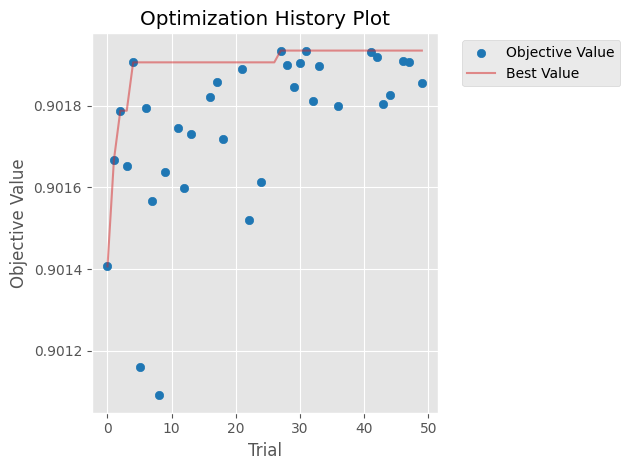

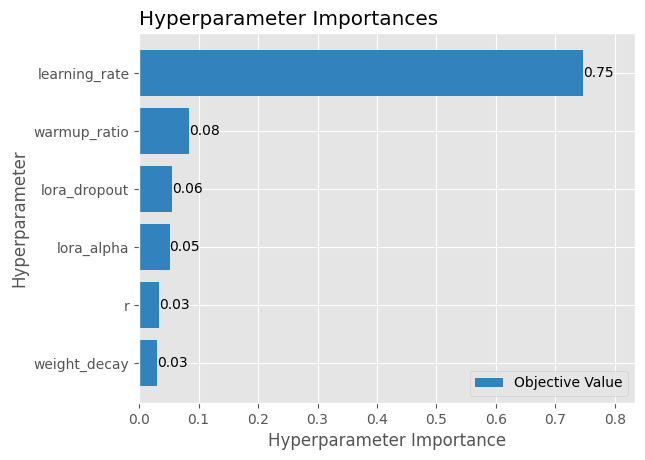

,rank,trial_number,trial_name,value,learning_rate,r,lora_alpha,lora_dropout,weight_decay,warmup_ratio
0,1,27,trial_028,0.901935,0.000249,8,32,0.00,0.001272,0.08
1,2,31,trial_032,0.901934,0.000300,4,64,0.15,0.008051,0.03
2,3,41,trial_042,0.901932,0.000298,4,64,0.15,0.006650,0.03
3,4,42,trial_043,0.901919,0.000295,4,64,0.15,0.005696,0.03
4,5,46,trial_047,0.901909,0.000298,4,64,0.05,0.002375,0.00


Kept Optuna checkpoint dirs: ['trial_028', 'trial_032', 'trial_042', 'trial_043', 'trial_047']


In [19]:
# =========================
# Optuna summary + keep only top5 checkpoints
# =========================
trials_df = study.trials_dataframe(attrs=("number", "value", "state", "params", "datetime_start", "datetime_complete"))
save_csv(trials_df, OUT_OPTUNA_STUDY / "study_trials.csv")
display(trials_df.sort_values("value", ascending=False).head(10))

completed_trials = [t for t in study.trials if t.state == TrialState.COMPLETE and t.value is not None]

if len(completed_trials) == 0:
    save_text(
        "Tidak ada trial COMPLETE. Cek log di logs/study_run.log dan logs/trial_failures.log",
        OUT_OPTUNA_STUDY / "NO_COMPLETED_TRIALS.txt"
    )
    raise RuntimeError(
        "Tidak ada trial COMPLETE di Optuna study. "
        "Cek logs/study_run.log dan logs/trial_failures.log sebelum lanjut."
    )

best_trial = max(completed_trials, key=lambda t: t.value)
best_trial_summary = {
    "number": best_trial.number,
    "value": float(best_trial.value),
    "params": best_trial.params,
}
save_json(best_trial_summary, OUT_OPTUNA_STUDY / "best_trial_summary.json")
print("Best trial:", best_trial_summary)

# matplotlib plots
try:
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

    ax = plot_optimization_history(study)
    fig = ax.figure
    save_and_maybe_show(fig, OUT_OPTUNA_STUDY / "optimization_history.png", show=DISPLAY_SUMMARY_PLOTS)

    ax = plot_param_importances(study)
    fig = ax.figure
    save_and_maybe_show(fig, OUT_OPTUNA_STUDY / "parameter_importance.png", show=DISPLAY_SUMMARY_PLOTS)

except Exception as e:
    print("Optuna matplotlib plots skipped:", repr(e))

completed_trials = sorted(completed_trials, key=lambda x: x.value, reverse=True)

topk_rows = []
keep_trial_names = set()

for rank, t in enumerate(completed_trials[:OPTUNA_TOPK], start=1):
    trial_name = f"trial_{t.number + 1:03d}"
    keep_trial_names.add(trial_name)
    topk_rows.append({
        "rank": rank,
        "trial_number": t.number,
        "trial_name": trial_name,
        "value": float(t.value),
        **t.params
    })

topk_df = pd.DataFrame(topk_rows)
save_csv(topk_df, OUT_OPTUNA_STUDY / "top5_trials.csv")
display(topk_df)

# remove checkpoints outside top5 to save storage
for ckpt_dir in sorted(CKPT_OPTUNA_TRIALS.glob("trial_*")):
    if ckpt_dir.name not in keep_trial_names:
        shutil.rmtree(ckpt_dir, ignore_errors=True)

print("Kept Optuna checkpoint dirs:", sorted(list(keep_trial_names)))

Cell 20 — Freeze best HP and save JSON + CSV

In [20]:
# =========================
# Freeze best HP
# =========================
BEST_HP = {
    "learning_rate": float(best_trial.params["learning_rate"]),
    "r": int(best_trial.params["r"]),
    "lora_alpha": int(best_trial.params["lora_alpha"]),
    "lora_dropout": float(best_trial.params["lora_dropout"]),
    "weight_decay": float(best_trial.params["weight_decay"]),
    "warmup_ratio": float(best_trial.params["warmup_ratio"]),
}

save_json(BEST_HP, OUT_OPTUNA_STUDY / "best_hp.json")
save_csv(pd.DataFrame([BEST_HP]), OUT_OPTUNA_STUDY / "best_hp.csv")
print("BEST_HP:", BEST_HP)

BEST_HP: {'learning_rate': 0.0002490564837914727, 'r': 8, 'lora_alpha': 32, 'lora_dropout': 0.0, 'weight_decay': 0.0012718567841742577, 'warmup_ratio': 0.08}


Cell 21 - Final 10 runs

In [21]:
# =========================
# Final 10 runs
# =========================
final_run_rows = []

for idx, seed in enumerate(FINAL_SEEDS, start=1):
    run_name = f"run_{idx:02d}_seed_{seed:03d}"
    run_out_dir = OUT_FINAL_RUNS / run_name
    run_ckpt_dir = CKPT_FINAL_RUNS / run_name

    log_line(f"[FINAL] start {run_name}", STUDY_LOG)

    result = run_single_training(
        run_name=run_name,
        run_output_dir=run_out_dir,
        run_ckpt_dir=run_ckpt_dir,
        df_tr=df_train,
        df_va=df_val,
        df_te=df_test,
        seed=seed,
        hp=BEST_HP,
        is_optuna=False,
        trial=None,
        show_plots=DISPLAY_FINAL_RUN_PLOTS,
    )

    # hardening checks
    pred_test_path = run_out_dir / "predictions_test_strict.csv"
    assert pred_test_path.exists(), f"Missing test prediction CSV: {pred_test_path}"

    df_pred_check = pd.read_csv(pred_test_path)
    assert len(df_pred_check) == len(df_test), (
        f"Jumlah row prediksi test tidak sama dengan df_test pada {run_name}: "
        f"{len(df_pred_check)} vs {len(df_test)}"
    )
    assert df_pred_check["clip_id"].is_unique, f"clip_id tidak unik di {pred_test_path}"

    rs = result["run_summary"]
    final_run_rows.append({
        "run_id": run_name,
        "seed": seed,
        "best_epoch": rs["best_epoch"],
        "stop_epoch": rs["stop_epoch"],
        "best_val_S": rs["best_val_S"],
        "test_MAE_mean": rs.get("test_mae_mean", np.nan),
        "test_RMSE_mean": rs.get("test_rmse_mean", np.nan),
        "test_R2_mean": rs.get("test_r2_mean", np.nan),
        "test_Acc_mean": rs.get("test_acc_mean", np.nan),
    })

    log_line(f"[FINAL] done {run_name} | test_S={rs.get('test_S', np.nan):.6f}", STUDY_LOG)
    del df_pred_check
    del result
    gpu_flush()

final_runs_summary = pd.DataFrame(final_run_rows)
save_csv(final_runs_summary, OUT_FINAL_AGG / "final_runs_summary.csv")
display(final_runs_summary)

[2026-04-19 23:26:13] [FINAL] start run_01_seed_042


Loading weights:   0%|          | 0/248 [00:00<?, ?it/s]

[run_01_seed_042] epochs:   0%|          | 0/100 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

...

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

train:   0%|          | 0/149 [00:00<?, ?it/s]

[2026-04-20 14:22:38] [FINAL] done run_10_seed_132 | test_S=0.899843


,run_id,seed,best_epoch,stop_epoch,best_val_S,test_MAE_mean,test_RMSE_mean,test_R2_mean,test_Acc_mean
0,run_01_seed_042,42,24,29,0.901935,0.100190,0.126587,0.303067,0.899810
1,run_02_seed_052,52,20,25,0.901672,0.100338,0.126723,0.301679,0.899662
2,run_03_seed_062,62,21,26,0.901894,0.100174,0.126508,0.304086,0.899826
3,run_04_seed_072,72,23,28,0.901856,0.100350,0.126765,0.300896,0.899650
4,run_05_seed_082,82,24,29,0.901691,0.100302,0.126842,0.300112,0.899698
5,run_06_seed_092,92,19,24,0.901748,0.100288,0.126567,0.303232,0.899712
6,run_07_seed_102,102,17,22,0.901874,0.100253,0.126471,0.304404,0.899747
7,run_08_seed_112,112,17,22,0.901810,0.100405,0.126578,0.303256,0.899595
8,run_09_seed_122,122,29,34,0.901893,0.100296,0.126615,0.302902,0.899704
9,run_10_seed_132,132,29,34,0.901911,0.100157,0.126609,0.302933,0.899843


Cell 22 - Aggregate statistics, epoch behavior, validation stability

,best_val_S_mean,best_val_S_std,best_val_S_min,best_val_S_max,best_val_S_p10,best_val_S_p50,best_val_S_p90,best_val_S_ci95_low,best_val_S_ci95_high,test_MAE_mean_mean,...,best_epoch_ci95_high,stop_epoch_mean,stop_epoch_std,stop_epoch_min,stop_epoch_max,stop_epoch_p10,stop_epoch_p50,stop_epoch_p90,stop_epoch_ci95_low,stop_epoch_ci95_high
0,0.901828,0.000094,0.901672,0.901935,0.901689,0.901865,0.901914,0.90177,0.901887,0.100275,...,24.994555,27.3,4.347413,22.0,34.0,22.0,27.0,34.0,24.605445,29.994555


,metric,mean,std,ci95_low,ci95_high
0,best_val_S,0.901828,0.000094,0.901770,0.901887
1,test_MAE_mean,0.100275,0.000081,0.100225,0.100326
2,test_RMSE_mean,0.126627,0.000116,0.126555,0.126698
3,test_R2_mean,0.302657,0.001359,0.301814,0.303499
4,test_Acc_mean,0.899725,0.000081,0.899674,0.899775


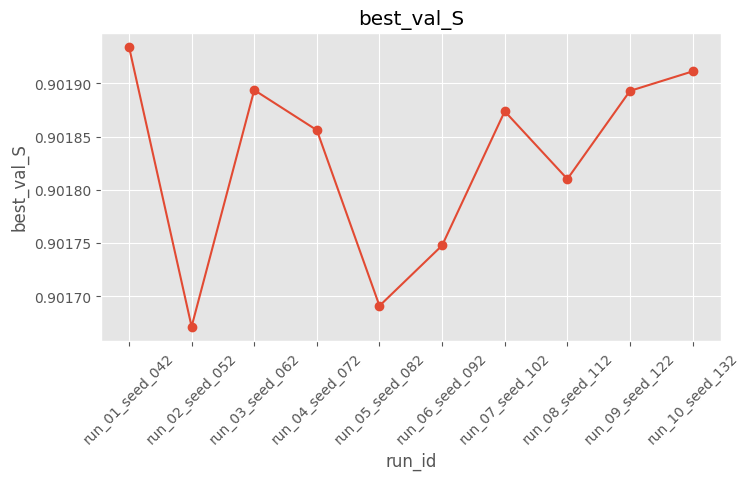

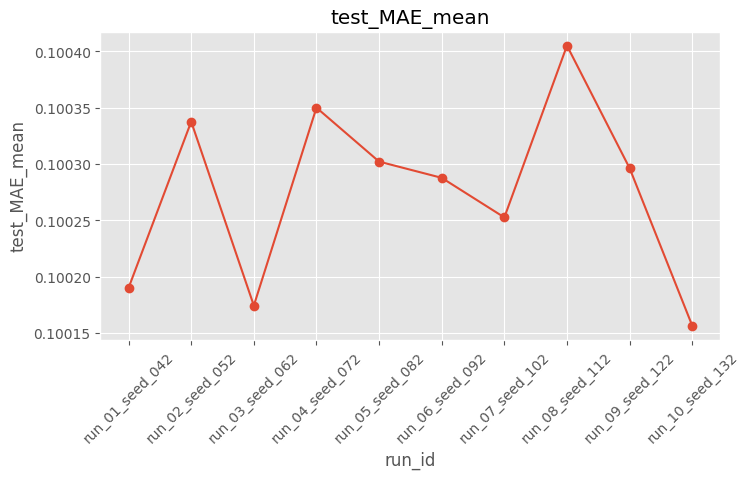

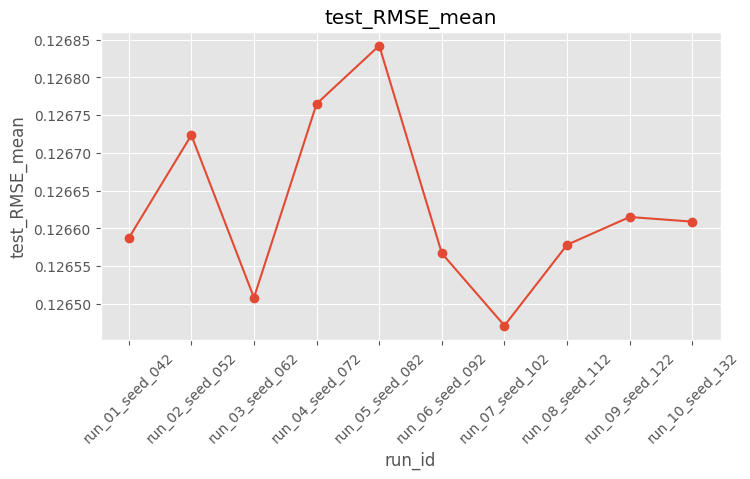

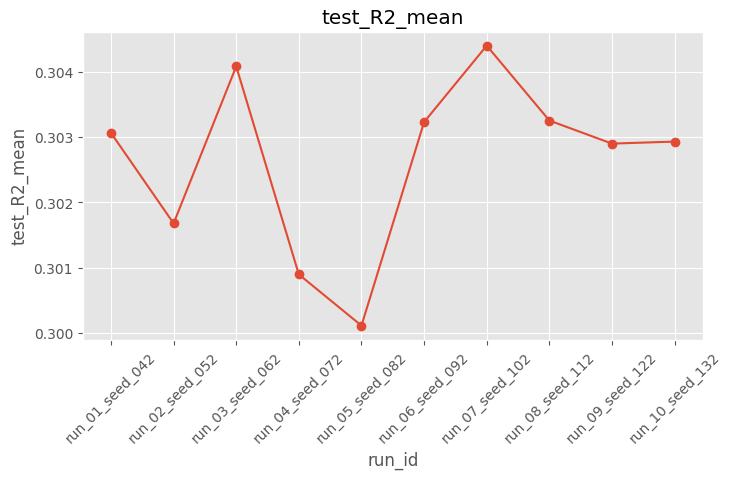

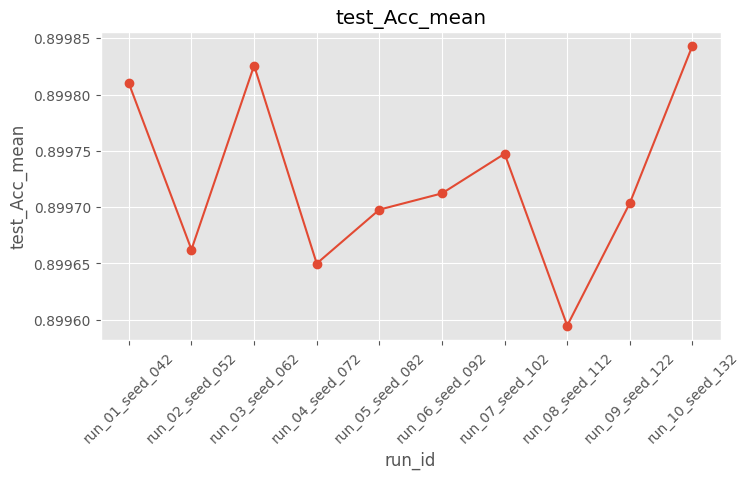

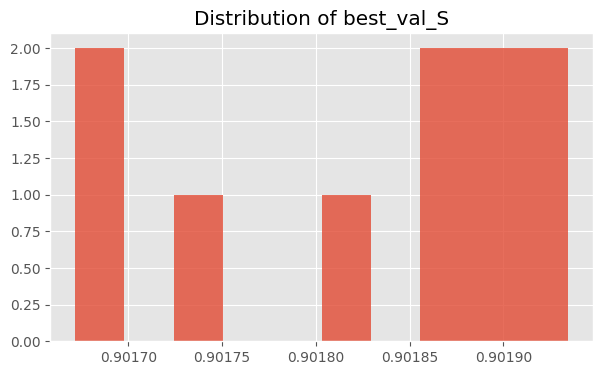

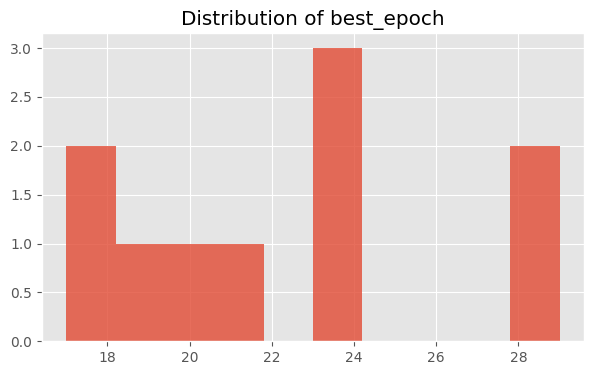

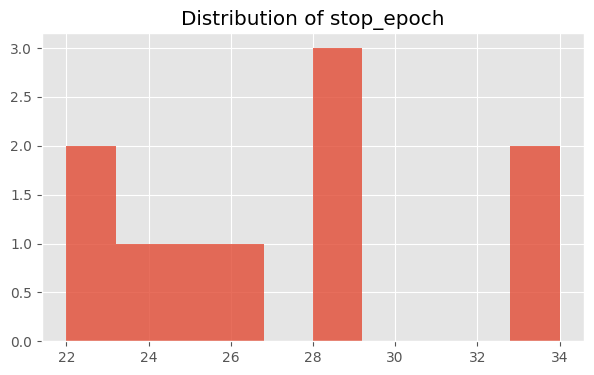

In [22]:
# =========================
# Aggregate stats
# =========================
def summarize_series(x: pd.Series, prefix: str) -> Dict:
    arr = x.dropna().values.astype(float)
    if len(arr) == 0:
        return {}
    mean = arr.mean()
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    ci95 = 1.96 * std / math.sqrt(len(arr)) if len(arr) > 1 else 0.0
    return {
        f"{prefix}_mean": mean,
        f"{prefix}_std": std,
        f"{prefix}_min": float(np.min(arr)),
        f"{prefix}_max": float(np.max(arr)),
        f"{prefix}_p10": float(np.percentile(arr, 10)),
        f"{prefix}_p50": float(np.percentile(arr, 50)),
        f"{prefix}_p90": float(np.percentile(arr, 90)),
        f"{prefix}_ci95_low": mean - ci95,
        f"{prefix}_ci95_high": mean + ci95,
    }

stats = {}
for col in ["best_val_S", "test_MAE_mean", "test_RMSE_mean", "test_R2_mean", "test_Acc_mean", "best_epoch", "stop_epoch"]:
    stats.update(summarize_series(final_runs_summary[col], col))

stats_df = pd.DataFrame([stats])
save_csv(stats_df, OUT_FINAL_AGG / "final_stats_summary.csv")
save_json(stats, OUT_FINAL_AGG / "final_stats_summary.json")
display(stats_df)

# CI report
ci_rows = []
for col in ["best_val_S", "test_MAE_mean", "test_RMSE_mean", "test_R2_mean", "test_Acc_mean"]:
    ci_rows.append({
        "metric": col,
        "mean": stats[f"{col}_mean"],
        "std": stats[f"{col}_std"],
        "ci95_low": stats[f"{col}_ci95_low"],
        "ci95_high": stats[f"{col}_ci95_high"],
    })
ci_df = pd.DataFrame(ci_rows)
save_csv(ci_df, OUT_FINAL_AGG / "ci_95_report.csv")
display(ci_df)

# epoch behavior
epoch_behavior_df = final_runs_summary[["run_id", "seed", "best_epoch", "stop_epoch"]].copy()
save_csv(epoch_behavior_df, OUT_FINAL_AGG / "epoch_behavior.csv")

# validation stability
validation_stability_df = final_runs_summary[["run_id", "seed", "best_val_S", "test_MAE_mean", "test_RMSE_mean", "test_R2_mean", "test_Acc_mean"]].copy()
save_csv(validation_stability_df, OUT_FINAL_AGG / "validation_stability.csv")

# distributions / ringkasan tambahan
best_epoch_dist = epoch_behavior_df["best_epoch"].value_counts().sort_index().reset_index()
best_epoch_dist.columns = ["best_epoch", "count"]
save_csv(best_epoch_dist, OUT_FINAL_AGG / "best_epoch_distribution.csv")

stop_epoch_dist = epoch_behavior_df["stop_epoch"].value_counts().sort_index().reset_index()
stop_epoch_dist.columns = ["stop_epoch", "count"]
save_csv(stop_epoch_dist, OUT_FINAL_AGG / "stop_epoch_distribution.csv")

best_val_S_values = final_runs_summary[["run_id", "seed", "best_val_S"]].sort_values("best_val_S", ascending=False).reset_index(drop=True)
save_csv(best_val_S_values, OUT_FINAL_AGG / "best_val_S_distribution.csv")

# aggregate plots
for col in ["best_val_S", "test_MAE_mean", "test_RMSE_mean", "test_R2_mean", "test_Acc_mean"]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(final_runs_summary["run_id"], final_runs_summary[col], marker="o")
    ax.set_title(col)
    ax.set_xlabel("run_id")
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=45)
    save_and_maybe_show(fig, OUT_FINAL_AGG / f"curve_{col}_across_runs.png", show=DISPLAY_SUMMARY_PLOTS)

for col in ["best_val_S", "best_epoch", "stop_epoch"]:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(final_runs_summary[col].values, bins=min(10, len(final_runs_summary)), alpha=0.8)
    ax.set_title(f"Distribution of {col}")
    save_and_maybe_show(fig, OUT_FINAL_AGG / f"hist_{col}.png", show=DISPLAY_SUMMARY_PLOTS)

Cell 23 — Select best-val and median runs

In [23]:
# =========================
# Select best-val & median runs
# =========================
best_row = final_runs_summary.sort_values("best_val_S", ascending=False).iloc[0]
sorted_by_val = final_runs_summary.sort_values("best_val_S", ascending=True).reset_index(drop=True)
median_row = sorted_by_val.iloc[len(sorted_by_val) // 2]

selected_info = {
    "best_val": best_row.to_dict(),
    "median": median_row.to_dict(),
}
save_json(selected_info, OUT_FINAL_AGG / "selected_runs_summary.json")

print("BEST-VAL RUN")
display(pd.DataFrame([best_row.to_dict()]))

print("MEDIAN RUN")
display(pd.DataFrame([median_row.to_dict()]))

BEST-VAL RUN


,run_id,seed,best_epoch,stop_epoch,best_val_S,test_MAE_mean,test_RMSE_mean,test_R2_mean,test_Acc_mean
0,run_01_seed_042,42,24,29,0.901935,0.10019,0.126587,0.303067,0.89981


MEDIAN RUN


,run_id,seed,best_epoch,stop_epoch,best_val_S,test_MAE_mean,test_RMSE_mean,test_R2_mean,test_Acc_mean
0,run_07_seed_102,102,17,22,0.901874,0.100253,0.126471,0.304404,0.899747


Cell 24 — Copy selected outputs and checkpoints

In [24]:
# =========================
# Copy selected outputs
# =========================
def copy_selected_run(run_id: str, out_target_dir: Path, ckpt_target_dir: Path):
    src_out = OUT_FINAL_RUNS / run_id
    src_ckpt = CKPT_FINAL_RUNS / run_id

    out_target_dir.mkdir(parents=True, exist_ok=True)
    ckpt_target_dir.mkdir(parents=True, exist_ok=True)

    # copy CSV/JSON utama dengan nama asli (lebih bersih)
    for fname in [
        "predictions_val.csv",
        "predictions_val_best.csv",
        "predictions_test_strict.csv",
        "best_val_metrics.json",
        "last_val_metrics.json",
        "test_metrics.json",
        "run_summary.json",
        "history.csv",
    ]:
        src = src_out / fname
        if src.exists():
            shutil.copy2(src, out_target_dir / fname)

    # copy semua curve_*.png, scatter_*.png, hist_*.png
    for pattern in ["curve_*.png", "scatter_*.png", "hist_*.png"]:
        for src in src_out.glob(pattern):
            shutil.copy2(src, out_target_dir / src.name)

    # copy checkpoint
    if src_ckpt.exists():
        shutil.copytree(src_ckpt, ckpt_target_dir, dirs_exist_ok=True)

copy_selected_run(
    run_id=best_row["run_id"],
    out_target_dir=OUT_FINAL_SELECTED / "best_val",
    ckpt_target_dir=CKPT_SELECTED_BEST,
)

copy_selected_run(
    run_id=median_row["run_id"],
    out_target_dir=OUT_FINAL_SELECTED / "median",
    ckpt_target_dir=CKPT_SELECTED_MEDIAN,
)

Cell 25 — Ensemble simple average

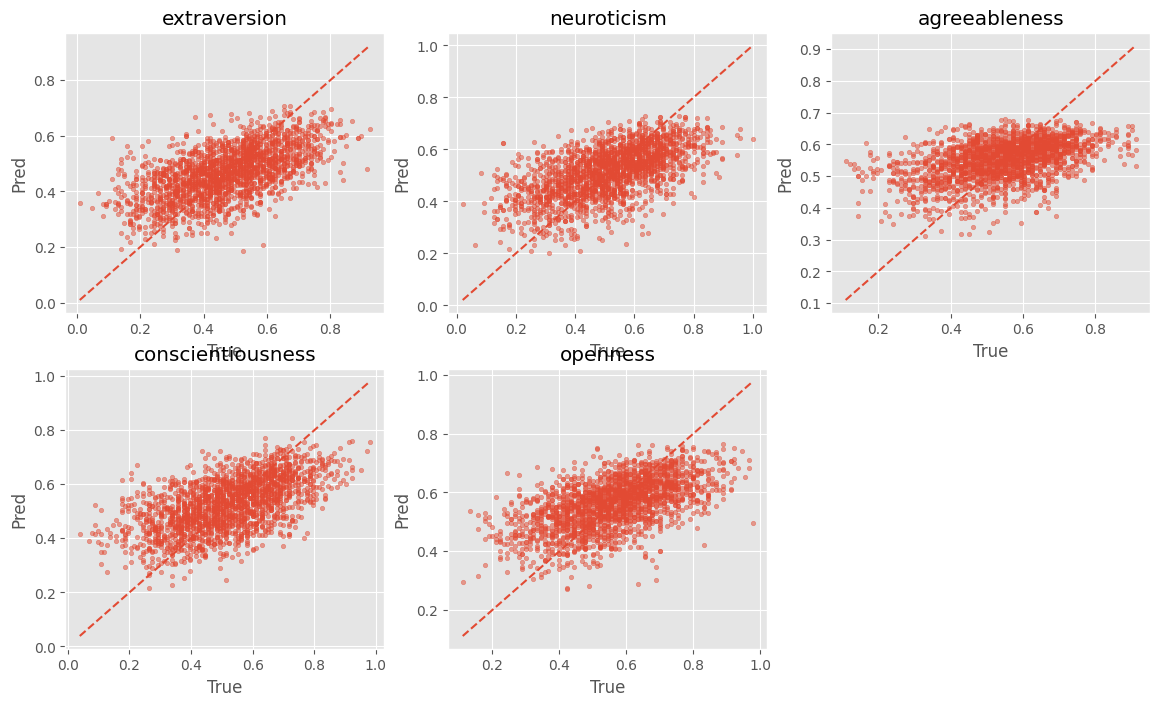

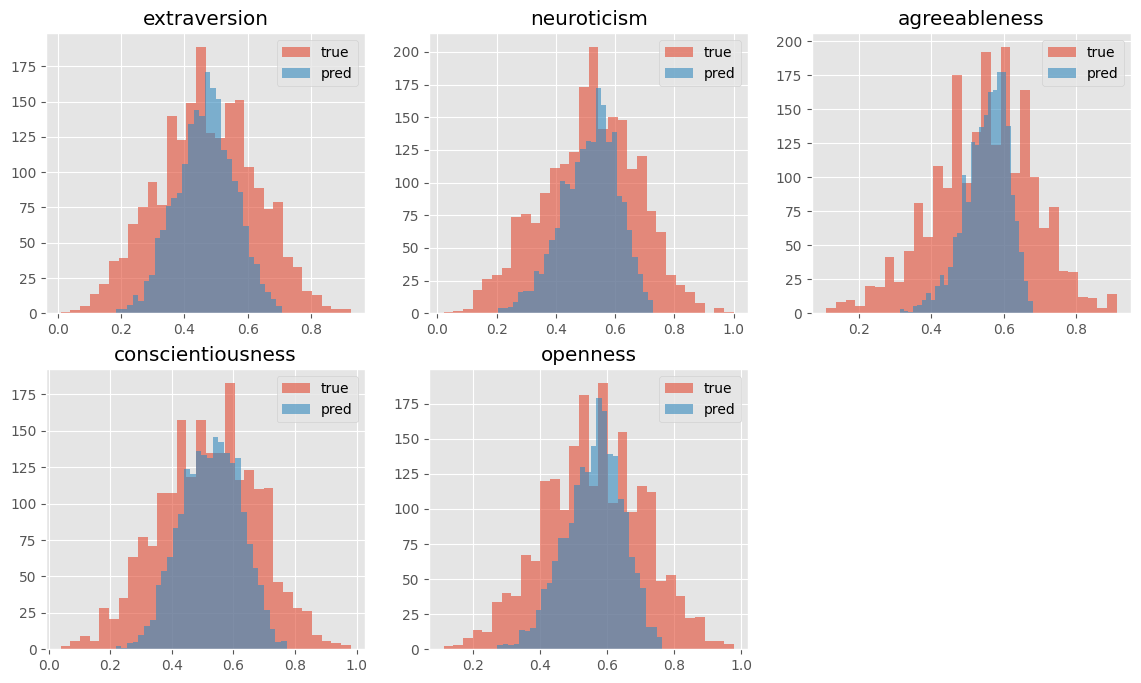

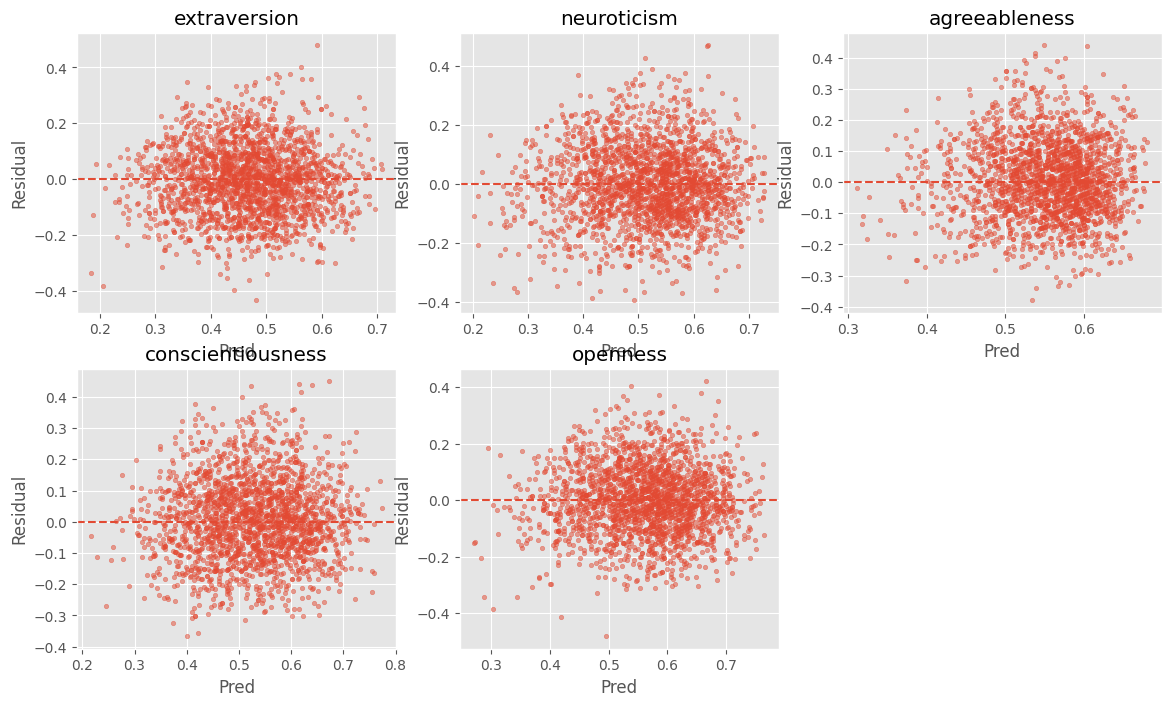

,mae_mean,rmse_mean,r2_mean,acc_mean,S,mae_extraversion,rmse_extraversion,r2_extraversion,acc_extraversion,mae_neuroticism,...,r2_agreeableness,acc_agreeableness,mae_conscientiousness,rmse_conscientiousness,r2_conscientiousness,acc_conscientiousness,mae_openness,rmse_openness,r2_openness,acc_openness
0,0.100132,0.12645,0.304565,0.899868,0.899868,0.09908,0.124683,0.347798,0.90092,0.102329,...,0.191499,0.901207,0.103327,0.130553,0.326877,0.896673,0.097131,0.122873,0.319988,0.902869


In [25]:
# =========================
# Ensemble simple average
# =========================
pred_dfs = []
ensemble_sources = []

reference_clip_ids = None
reference_len = None

for _, row in final_runs_summary.iterrows():
    run_id = row["run_id"]
    pred_path = OUT_FINAL_RUNS / run_id / "predictions_test_strict.csv"
    assert pred_path.exists(), f"Missing prediction CSV: {pred_path}"

    dfp = pd.read_csv(pred_path).sort_values("clip_id").reset_index(drop=True)

    if reference_len is None:
        reference_len = len(dfp)
        reference_clip_ids = dfp["clip_id"].tolist()
    else:
        assert len(dfp) == reference_len, (
            f"Jumlah row prediction tidak sama antar run. "
            f"Run {run_id}: {len(dfp)} vs ref {reference_len}"
        )
        assert dfp["clip_id"].tolist() == reference_clip_ids, (
            f"Daftar clip_id tidak identik dengan reference pada run {run_id}"
        )

    pred_dfs.append(dfp)
    ensemble_sources.append({
        "run_id": run_id,
        "checkpoint_dir": str(CKPT_FINAL_RUNS / run_id),
        "prediction_csv": str(pred_path),
    })

base = pred_dfs[0][["clip_id"] + [f"true_{c}" for c in LABEL_COLS]].copy()

for col in LABEL_COLS:
    stack = np.stack([d[f"pred_{col}"].values for d in pred_dfs], axis=0)
    base[f"pred_{col}"] = stack.mean(axis=0)
    base[f"abs_err_{col}"] = np.abs(base[f"pred_{col}"] - base[f"true_{col}"])

base["mae_per_sample"] = base[[f"abs_err_{c}" for c in LABEL_COLS]].mean(axis=1)

y_true = base[[f"true_{c}" for c in LABEL_COLS]].values
y_pred = base[[f"pred_{c}" for c in LABEL_COLS]].values
ens_metrics = compute_metrics_from_arrays(y_true, y_pred)
ens_metrics_flat = metrics_to_flat_dict(ens_metrics)

ENS_OUT = OUT_FINAL_SELECTED / "ensemble"
ENS_OUT.mkdir(parents=True, exist_ok=True)

save_csv(base, ENS_OUT / "ensemble_predictions_test_strict.csv")
save_json(ens_metrics_flat, ENS_OUT / "ensemble_metrics.json")
save_json({"sources": ensemble_sources}, ENS_OUT / "ensemble_sources.json")
save_json({"sources": ensemble_sources}, CKPT_SELECTED_ENSEMBLE / "ensemble_sources.json")

plot_pred_vs_true(base, ENS_OUT, tag="ensemble", show=DISPLAY_SUMMARY_PLOTS)
display(pd.DataFrame([ens_metrics_flat]))

Cell 26 — Appendix-ready exports

In [26]:
# =========================
# Appendix-ready files
# =========================
BEST_VAL_PRED = OUT_FINAL_SELECTED / "best_val" / "predictions_test_strict.csv"
MEDIAN_PRED = OUT_FINAL_SELECTED / "median" / "predictions_test_strict.csv"
ENS_PRED = OUT_FINAL_SELECTED / "ensemble" / "ensemble_predictions_test_strict.csv"

copy_if_exists(BEST_VAL_PRED, OUT_APPENDIX / "appendix_best_val_predictions_test_strict.csv")
copy_if_exists(MEDIAN_PRED, OUT_APPENDIX / "appendix_median_predictions_test_strict.csv")
copy_if_exists(ENS_PRED, OUT_APPENDIX / "appendix_ensemble_predictions_test_strict.csv")

copy_if_exists(OUT_FINAL_AGG / "final_runs_summary.csv", OUT_APPENDIX / "appendix_final_runs_summary.csv")
copy_if_exists(OUT_FINAL_AGG / "final_stats_summary.csv", OUT_APPENDIX / "appendix_final_stats_summary.csv")
copy_if_exists(OUT_FINAL_AGG / "final_stats_summary.json", OUT_APPENDIX / "appendix_final_stats_summary.json")
copy_if_exists(OUT_FINAL_AGG / "selected_runs_summary.json", OUT_APPENDIX / "appendix_selected_run_info.json")

copy_if_exists(OUT_FINAL_SELECTED / "best_val" / "best_val_metrics.json", OUT_APPENDIX / "appendix_best_val_metrics.json")

print("Appendix-ready files:")
for p in sorted(OUT_APPENDIX.glob("*")):
    print("-", p.name)

Appendix-ready files:
- appendix_best_val_metrics.json
- appendix_best_val_predictions_test_strict.csv
- appendix_ensemble_predictions_test_strict.csv
- appendix_final_runs_summary.csv
- appendix_final_stats_summary.csv
- appendix_final_stats_summary.json
- appendix_median_predictions_test_strict.csv
- appendix_selected_run_info.json


Cell 27 — Extra analysis for R² kecil

In [27]:
# =========================
# Extra analysis for R2 vs 1-MAE
# =========================
df_best = pd.read_csv(BEST_VAL_PRED)

analysis_rows = []
for col in LABEL_COLS:
    true_vals = df_best[f"true_{col}"].values
    pred_vals = df_best[f"pred_{col}"].values

    true_var = float(np.var(true_vals))
    pred_var = float(np.var(pred_vals))
    compression = float(pred_var / true_var) if true_var > 1e-12 else np.nan
    corr = float(np.corrcoef(true_vals, pred_vals)[0, 1]) if len(true_vals) > 1 else np.nan

    analysis_rows.append({
        "trait": col,
        "true_mean": float(np.mean(true_vals)),
        "true_var": true_var,
        "true_min": float(np.min(true_vals)),
        "true_max": float(np.max(true_vals)),
        "pred_mean": float(np.mean(pred_vals)),
        "pred_var": pred_var,
        "pred_min": float(np.min(pred_vals)),
        "pred_max": float(np.max(pred_vals)),
        "pred_var_over_true_var": compression,
        "corr_true_pred": corr,
        "mae": float(np.mean(np.abs(pred_vals - true_vals))),
        "rmse": float(np.sqrt(np.mean((pred_vals - true_vals) ** 2))),
        "r2": float(r2_score(true_vals, pred_vals)),
    })

df_analysis = pd.DataFrame(analysis_rows)
save_csv(df_analysis, OUT_FINAL_AGG / "r2_vs_mae_analysis.csv")
display(df_analysis)

df_best_sorted = df_best.sort_values("mae_per_sample", ascending=False).reset_index(drop=True)
save_csv(df_best_sorted.head(20), OUT_FINAL_AGG / "top20_worst_predictions.csv")
save_csv(df_best_sorted.tail(20), OUT_FINAL_AGG / "top20_best_predictions.csv")

print("\nNarrative helper:")
print("- 1-MAE tinggi bisa terjadi karena MAE pada skala 0..1 relatif kecil.")
print("- R2 tetap kecil bila variasi target tidak tertangkap kuat atau prediksi cenderung ke tengah.")
print("- Kolom pred_var_over_true_var membantu melihat apakah sebaran prediksi lebih sempit daripada target.")

,trait,true_mean,true_var,true_min,true_max,pred_mean,pred_var,pred_min,pred_max,pred_var_over_true_var,corr_true_pred,mae,rmse,r2
0,extraversion,0.470627,0.023836,0.009346,0.925234,0.468313,0.008350,0.181396,0.716309,0.350299,0.590178,0.098991,0.124656,0.348083
1,neuroticism,0.513191,0.025390,0.020833,1.000000,0.516724,0.009476,0.200439,0.741699,0.373203,0.580374,0.102272,0.129901,0.335410
2,agreeableness,0.543479,0.019130,0.109890,0.912088,0.551693,0.003907,0.306885,0.683594,0.204223,0.440674,0.098856,0.124438,0.190541
3,conscientiousness,0.518315,0.025321,0.038835,0.980583,0.526814,0.009318,0.214966,0.777344,0.368005,0.573416,0.103458,0.130749,0.324850
4,openness,0.560553,0.022202,0.111111,0.977778,0.565540,0.007561,0.264648,0.770508,0.340535,0.563878,0.097374,0.123192,0.316450



Narrative helper:
- 1-MAE tinggi bisa terjadi karena MAE pada skala 0..1 relatif kecil.
- R2 tetap kecil bila variasi target tidak tertangkap kuat atau prediksi cenderung ke tengah.
- Kolom pred_var_over_true_var membantu melihat apakah sebaran prediksi lebih sempit daripada target.


In [28]:
# =========================
# Extra artifact — per-trait summary for best-val test strict
# =========================
df_best = pd.read_csv(BEST_VAL_PRED)

rows = []
for col in LABEL_COLS:
    y_true = df_best[f"true_{col}"].values
    y_pred = df_best[f"pred_{col}"].values
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    r2 = float(r2_score(y_true, y_pred))
    acc = float(1.0 - mae)
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) > 1 else np.nan
    rows.append({
        "trait": col,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "acc_1_minus_mae": acc,
        "corr_true_pred": corr,
        "true_mean": float(np.mean(y_true)),
        "pred_mean": float(np.mean(y_pred)),
        "true_std": float(np.std(y_true)),
        "pred_std": float(np.std(y_pred)),
    })

df_best_trait_summary = pd.DataFrame(rows)
save_csv(df_best_trait_summary, OUT_FINAL_AGG / "best_val_test_trait_summary.csv")
display(df_best_trait_summary)

,trait,mae,rmse,r2,acc_1_minus_mae,corr_true_pred,true_mean,pred_mean,true_std,pred_std
0,extraversion,0.098991,0.124656,0.348083,0.901009,0.590178,0.470627,0.468313,0.154389,0.091377
1,neuroticism,0.102272,0.129901,0.335410,0.897728,0.580374,0.513191,0.516724,0.159343,0.097343
2,agreeableness,0.098856,0.124438,0.190541,0.901144,0.440674,0.543479,0.551693,0.138310,0.062504
3,conscientiousness,0.103458,0.130749,0.324850,0.896542,0.573416,0.518315,0.526814,0.159125,0.096531
4,openness,0.097374,0.123192,0.316450,0.902626,0.563878,0.560553,0.565540,0.149004,0.086952


In [29]:
# =========================
# Extra artifact — bin analysis true vs pred
# =========================
bin_rows = []

for col in LABEL_COLS:
    temp = df_best[[f"true_{col}", f"pred_{col}"]].copy()
    temp.columns = ["true", "pred"]

    temp["bin"] = pd.qcut(temp["true"], q=5, duplicates="drop")

    grp = temp.groupby("bin", observed=False).agg(
        true_mean=("true", "mean"),
        pred_mean=("pred", "mean"),
        count=("true", "size")
    ).reset_index()

    grp["trait"] = col
    grp["gap_pred_minus_true"] = grp["pred_mean"] - grp["true_mean"]
    bin_rows.append(grp)

df_bin_analysis = pd.concat(bin_rows, ignore_index=True)
save_csv(df_bin_analysis, OUT_FINAL_AGG / "best_val_test_bin_analysis.csv")
display(df_bin_analysis.head(20))

,bin,true_mean,pred_mean,count,trait,gap_pred_minus_true
0,"(0.00835, 0.336]",0.254656,0.394521,427,extraversion,0.139865
1,"(0.336, 0.43]",0.391888,0.440090,412,extraversion,0.048201
2,"(0.43, 0.514]",0.474376,0.462320,393,extraversion,-0.012057
3,"(0.514, 0.607]",0.560906,0.502595,413,extraversion,-0.058311
4,"(0.607, 0.925]",0.688647,0.547839,394,extraversion,-0.140808
5,"(0.019799999999999998, 0.375]",0.283799,0.432906,425,neuroticism,0.149107
6,"(0.375, 0.479]",0.435820,0.488822,403,neuroticism,0.053002
7,"(0.479, 0.562]",0.523674,0.517653,418,neuroticism,-0.006021
8,"(0.562, 0.656]",0.613106,0.558777,423,neuroticism,-0.054329
9,"(0.656, 1.0]",0.734882,0.594266,370,neuroticism,-0.140616


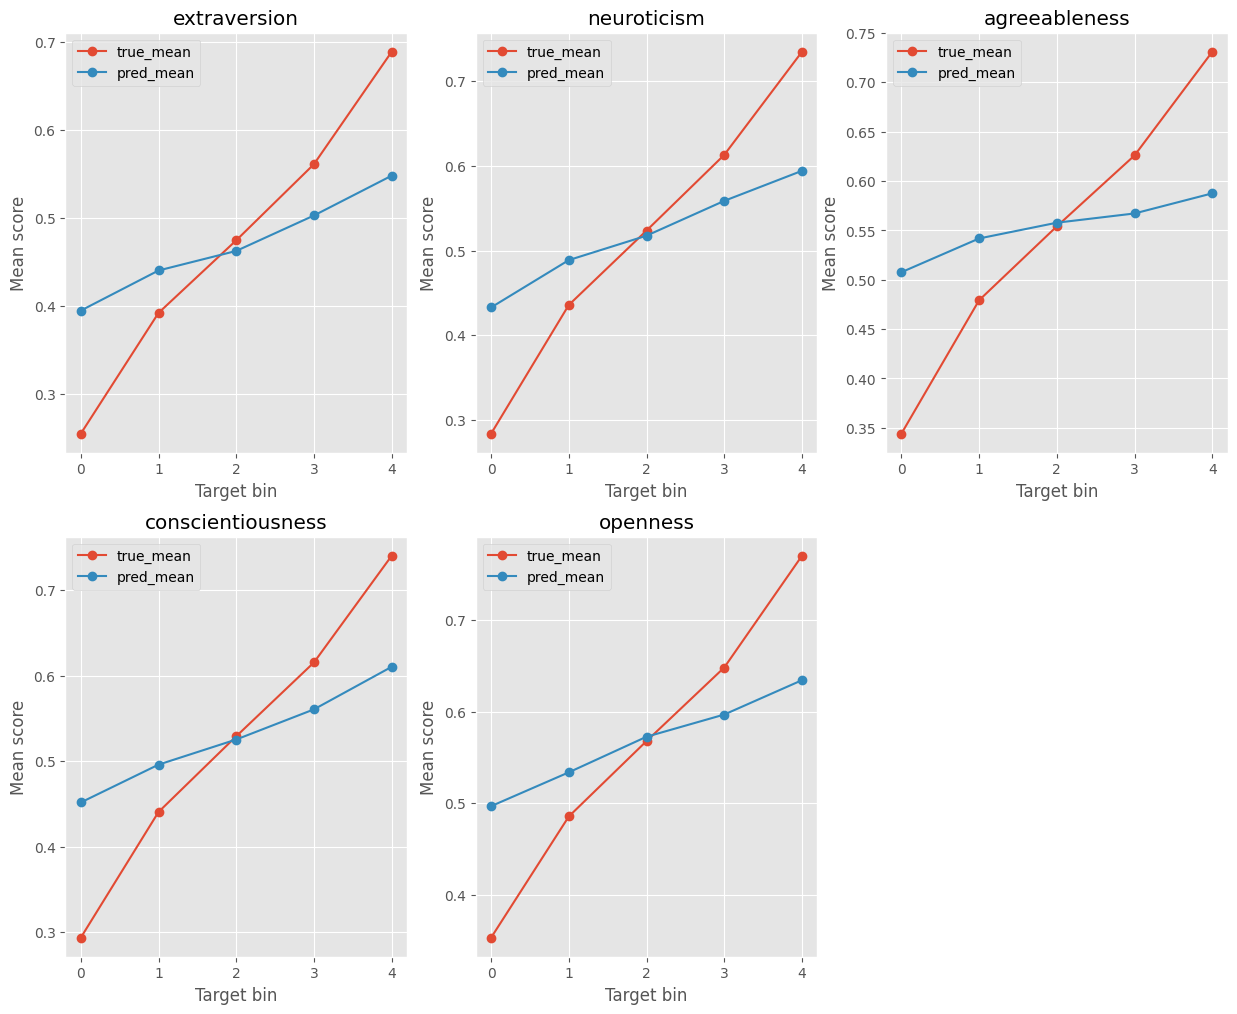

In [33]:
# =========================
# Extra artifact — plot bin analysis
# =========================
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    ax = axes[i]
    sub = df_bin_analysis[df_bin_analysis["trait"] == col].copy().reset_index(drop=True)
    ax.plot(range(len(sub)), sub["true_mean"], marker="o", label="true_mean")
    ax.plot(range(len(sub)), sub["pred_mean"], marker="o", label="pred_mean")
    ax.set_title(col)
    ax.set_xlabel("Target bin")
    ax.set_ylabel("Mean score")
    ax.legend()

axes[-1].axis("off")
save_and_maybe_show(fig, OUT_FINAL_AGG / "best_val_test_bin_analysis.png", show=True)

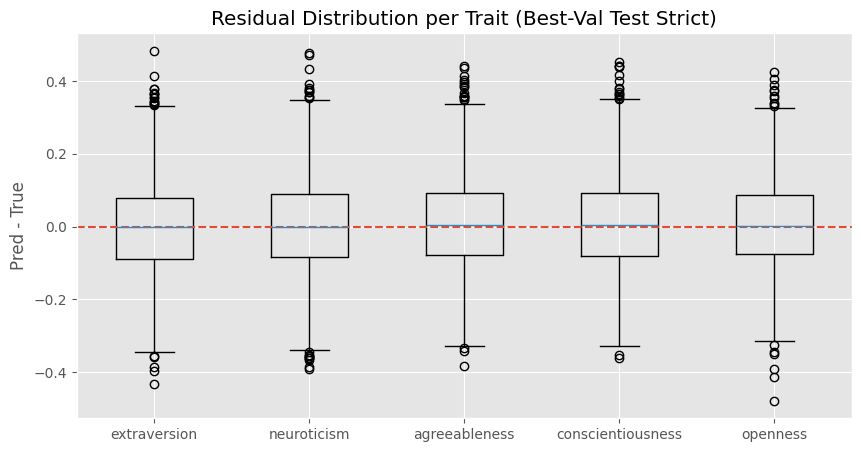

In [34]:
# =========================
# Extra artifact — residual boxplot per trait
# =========================
residual_long = []

for col in LABEL_COLS:
    residual = df_best[f"pred_{col}"].values - df_best[f"true_{col}"].values
    for v in residual:
        residual_long.append({
            "trait": col,
            "residual": float(v)
        })

df_residual_long = pd.DataFrame(residual_long)
save_csv(df_residual_long, OUT_FINAL_AGG / "best_val_test_residuals_long.csv")

fig, ax = plt.subplots(figsize=(10, 5))
data = [df_residual_long[df_residual_long["trait"] == col]["residual"].values for col in LABEL_COLS]
ax.boxplot(data, tick_labels=LABEL_COLS)
ax.axhline(0, linestyle="--")
ax.set_title("Residual Distribution per Trait (Best-Val Test Strict)")
ax.set_ylabel("Pred - True")
save_and_maybe_show(fig, OUT_FINAL_AGG / "best_val_test_residual_boxplot.png", show=True)

In [35]:
# =========================
# Extra artifact — copy important PNG to appendix
# =========================
important_pngs = [
    OUT_FINAL_AGG / "curve_test_MAE_mean_across_runs.png",
    OUT_FINAL_AGG / "curve_test_R2_mean_across_runs.png",
    OUT_FINAL_AGG / "best_val_test_bin_analysis.png",
    OUT_FINAL_AGG / "best_val_test_residual_boxplot.png",
    OUT_FINAL_SELECTED / "best_val" / "scatter_test_strict_pred_vs_true.png",
    OUT_FINAL_SELECTED / "best_val" / "hist_test_strict_pred_vs_true.png",
]

for src in important_pngs:
    if src.exists():
        shutil.copy2(src, OUT_APPENDIX / src.name)

print("PNG copied to appendix:")
for p in sorted(OUT_APPENDIX.glob("*.png")):
    print("-", p.name)

PNG copied to appendix:
- best_val_test_bin_analysis.png
- best_val_test_residual_boxplot.png
- curve_test_MAE_mean_across_runs.png
- curve_test_R2_mean_across_runs.png
- hist_test_strict_pred_vs_true.png
- scatter_test_strict_pred_vs_true.png


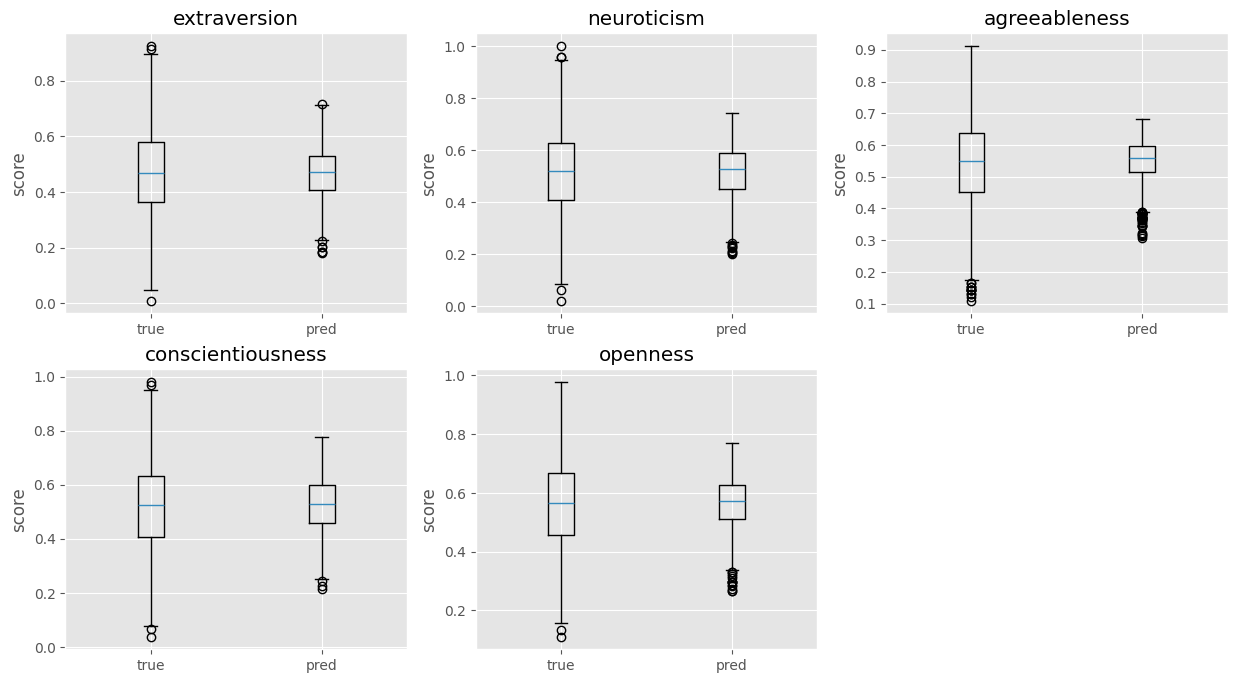

In [36]:
# =========================
# Extra artifact — boxplot true vs pred per trait (best-val test strict)
# =========================
df_best = pd.read_csv(BEST_VAL_PRED)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(LABEL_COLS):
    ax = axes[i]
    true_vals = df_best[f"true_{col}"].values
    pred_vals = df_best[f"pred_{col}"].values

    ax.boxplot([true_vals, pred_vals], tick_labels=["true", "pred"])
    ax.set_title(col)
    ax.set_ylabel("score")

axes[-1].axis("off")
save_and_maybe_show(fig, OUT_FINAL_AGG / "best_val_test_true_vs_pred_boxplot.png", show=True)